In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms

import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split

import torch.optim as optim
import torch.ao.quantization as quant
import pytorch_lightning as pl
from torchvision.models import resnet18

import torch_tensorrt

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import os
import sys
import time

sys.path.append(str(Path("../src").resolve()))
from spectogram_datamodule import SpektogramDataModule
from custom_transform import ShuffleChannels

FOLDER_PATH = Path(r"../spectogram_wieliczka")
TEST_FOLDER_PATH = Path(r"../spectogram_ziemowit")
NUM_CLASSES = 2

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
Unable to import quantize op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
TensorRT-LLM is not installed. Please install TensorRT-LLM or set TRTLLM_PLUGINS_PATH to the directory containing libnvinfer_plugin_tensorrt_llm.so to use converters for torch.distributed ops


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


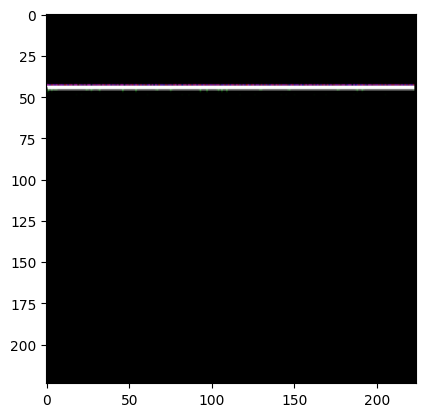

In [2]:
spectrogram_transforms = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224, 224)), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
    ShuffleChannels(0.5)
])

dm_wieliczka = SpektogramDataModule(FOLDER_PATH, spectrogram_transforms)
dm_wieliczka.setup()

dm_ziemowit = SpektogramDataModule(TEST_FOLDER_PATH, spectrogram_transforms, test_split=1, num_workers=0)
dm_ziemowit.setup()


plt.imshow(next(iter(dm_wieliczka.train_dataloader()))[0][3].numpy().transpose(1, 2, 0))

In [ ]:
class LitResNet(pl.LightningModule):
	def __init__(self, num_classes=10, lr=1e-3):
		super().__init__()
		self.save_hyperparameters()
		self.lr = lr

		self.model = resnet18(pretrained=False, num_classes=num_classes)
		self.criterion = nn.CrossEntropyLoss()


		self.train_loss_history = []
		self.train_acc_history = []

		self.val_loss_history = []
		self.val_acc_history = []

		self.test_loss_history = []
		self.test_acc_history = []

	def forward(self, x):
		# return self.model(x)
		x = self.model.conv1(x)
		x = self.model.bn1(x)
		x = self.model.relu(x)
		x = self.model.maxpool(x)
		x = self.model.layer1(x)
		x = self.model.layer2(x)
		x = self.model.layer3(x)
		x = self.model.layer4(x)
		x = self.model.avgpool(x)
		x = torch.flatten(x, 1)
		x = self.model.fc(x)

		return x



	def training_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()

		self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
		self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

		self.train_loss_history.append(loss.detach().cpu())
		self.train_acc_history.append(acc.detach().cpu())

		return loss


	def validation_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		self.val_loss_history.append(loss.detach().cpu())
		self.val_acc_history.append(acc.detach().cpu())
		self.log("val_loss", loss, on_epoch=True, prog_bar=True)
		self.log("val_acc", acc, on_epoch=True, prog_bar=True)
		return loss

	def test_step(self, batch, batch_idx):
		x, y = batch
		start_time = time.time()  
		
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		
		end_time = time.time()  
		
		batch_time = end_time - start_time  
		batch_size = x.size(0)
		fps = batch_size / batch_time  
		
		self.test_loss_history.append(loss.detach().cpu())
		self.test_acc_history.append(acc.detach().cpu())

		self.log("test_loss", loss, on_epoch=True, prog_bar=True)
		self.log("test_acc", acc, on_epoch=True, prog_bar=True)
		self.log("test_fps", fps, on_epoch=True, prog_bar=True)  
		
		return loss

	def configure_optimizers(self):
		return optim.SGD(self.parameters(), lr=self.lr, momentum=0.9)

In [4]:
model = LitResNet(num_classes=NUM_CLASSES, lr=1e-3)

trainer = pl.Trainer(
    precision=16,
    accelerator='gpu',
    devices=1,
    max_epochs=50
)

trainer.fit(model, dm_wieliczka)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | ResNet           | 11.2 M | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
--------------------------

Epoch 49: 100%|██████████| 5/5 [00:01<00:00,  4.85it/s, v_num=8, train_loss_step=0.0255, train_acc_step=1.000, val_loss=0.0103, val_acc=1.000, train_loss_epoch=0.0195, train_acc_epoch=0.993] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 5/5 [00:01<00:00,  2.77it/s, v_num=8, train_loss_step=0.0255, train_acc_step=1.000, val_loss=0.0103, val_acc=1.000, train_loss_epoch=0.0195, train_acc_epoch=0.993]


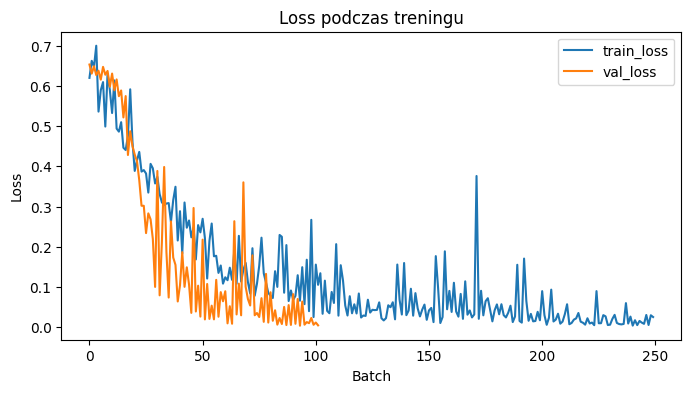

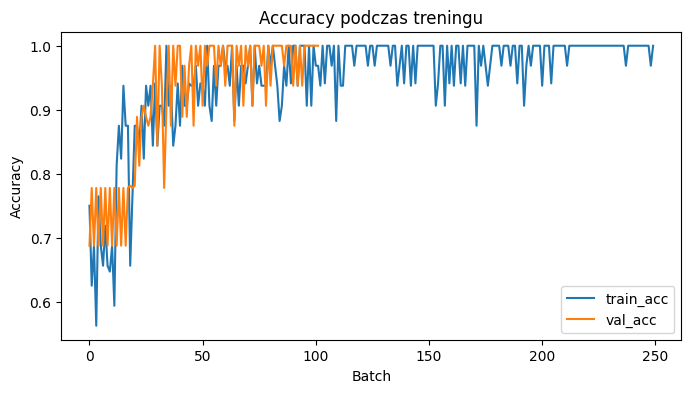

In [5]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,4))
plt.plot(model.train_loss_history, label="train_loss")
plt.plot(model.val_loss_history, label="val_loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Loss podczas treningu")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,4))
plt.plot(model.train_acc_history, label="train_acc")
plt.plot(model.val_acc_history, label="val_acc")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Accuracy podczas treningu")
plt.legend()
plt.show()


In [6]:
trainer.test(model, dm_ziemowit)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 17.27it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.32258063554763794
        test_fps               746.724609375
        test_loss            2.787895917892456
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.787895917892456,
  'test_acc': 0.32258063554763794,
  'test_fps': 746.724609375}]

In [7]:
# sample = next(iter(dm_ziemowit.test_dataloader()))[0][0]
# sample = sample.unsqueeze(0).cuda().half() 

# model.eval().cuda()

# trt_model = torch_tensorrt.compile(
#     model,
#     inputs=[torch_tensorrt.Input(sample.shape, dtype=torch.half)],
#     enabled_precisions={torch.half},
#     workspace_size=1 << 20
# )

# with torch.no_grad():
#     out = trt_model(sample)
# print(out.shape)

In [8]:
next(iter(dm_ziemowit.test_dataloader()))[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
sample = next(iter(dm_ziemowit.test_dataloader()))[0][0].unsqueeze(0).cuda().half()

model = model.eval().cuda().half()

torch.onnx.export(
    model,
    sample,
    "models/resnet18.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=12,          
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    do_constant_folding=True,     
)

W0117 02:40:10.546000 726466 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LitResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LitResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 16).
Failed to convert the model to the target version 16 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/patryk-magisterka/Desktop/venv/ML_venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/patryk-magisterka/Desktop/venv/ML_venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/patryk-magisterka/Desktop/venv/ML_venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 40 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.9.1+cu126',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT16,[s77,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT16,[1,2]>
            ),
            initializers=(
                %"model.fc.bias"<FLOAT16,[2]>{TorchTensor<FLOAT16,[2]>(Parameter containing: tensor([-0.0381,  0.0301], device='cuda:0', dtype=torch.float16, requires_grad=True), name='model.fc.bias')},
                %"model.conv1.weight"<FLOAT16,[64,3,7,7]>{Tensor(...)},
                %"model.layer1.0.conv1.weight"<FLOAT16,[64,64,3,3]>{Tensor(...)},
                %"model.layer1.0.conv2.weight"<FLOAT16,[64,64,3,3]>{Tensor(...)},
                %"model.layer1.1.conv1.weight"<FLOAT16,[64,64,3,3]>{Tensor(...)},

In [10]:
!pip install onnxscript

  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached onnx-1.20.1-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
  Using cached protobuf-6.33.4-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 5.8 MB/s eta 0:00:00m eta 0:00:010:01
Using cached onnx-1.20.1-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (17.5 MB)
Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 kB 7.3 MB/s eta 0:00:00
Using cached protobuf-6.33.4-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
